In [ ]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using DifferentialEquations
using Plots

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

In [ ]:
"""
计算 Chebyshev-Gauss-Lobatto 点及其积分权重
输入: N (多项式阶数，点的个数为 N+1)
输出: x (配置点), w (权重向量)
"""
function cheb_quad(N::Int)
    N_cheb = N

    x = [cos(pi * j / N) for j in 0:N]
    
    w = zeros(N + 1)
    
    n = 0:N
    for j in 0:N
        s = 0.0
        for k in 1:floor(Int, N/2)
            term = 2.0 / (1.0 - (2*k)^2) * cos(2 * k * j * pi / N)
            if 2*k == N
                s += 0.5 * term
            else
                s += term
            end
        end
        c_j = (j == 0 || j == N) ? 1.0 : 2.0
        w[j+1] = (c_j / N) * (1.0 + s)
    end
    a = 6
    b = 0.6
    c = 0.5
    Jac = zeros(N_cheb+1,N_cheb+1)
    x = reverse(x)
    for i = 1 : 1 : N_cheb + 1
        Jac[i,i] =(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2
    end
    Jac[end,end] = 1e10
    w1 = kron(I(5),diagm(Jac * w))
    w1 = w1[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))];
    return w1
end
x,w = cheb_quad(N_cheb)

In [182]:
N_cheb = 199
Ro = -1
Tw = 0.8
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

([0.0; 0.00041931631535658696; … ; 1.921467829537998e-8; 1.921467829537998e-8;;], [0.0; -0.0005065814261632294; … ; -0.99999997502322; -0.99999997502322;;], [-2.54080244936587e-25; -2.760052963536201e-7; … ; -0.8844730623111627; -0.8844730623111627;;], [0.8; 0.800060998443815; … ; 0.9999988643538507; 0.9999988643538507;;], [1.25; 1.2499046971981924; … ; 1.000001135647439; 1.000001135647439;;], [0.0; 0.0008224766983405118; … ; 20.0; 20.0;;], [-0.5333333333333333; -0.5333739989625432; … ; -0.6666659095692338; -0.6666659095692338;;], [1.1111111111111112; 1.1111958311719652; … ; 1.3888873116025704; 1.3888873116025704;;], [-2000.0757575761206 2431.8203198743795 … -0.1515245922914176 0.07575757575757575; -607.8848403830626 303.9234818057918 … 0.07575826344269207 -0.03787677150585497; … ; 4.5292157999911185e-10 -9.058996058085106e-10 … -3.634245953539955e-6 7.268944828659568e-6; -0.0 0.0 … -0.0 0.0], [2.400399850209574e6 -3.8142366014833706e6 … 605.14943514346 -302.55571408788325; 1.108681529

In [183]:
n = 30
num = 1
R = 600
omega = 4.0/R
be = n/R
Ma = Mr/R
c = 0.23-0.04im
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
vel_full,vel = eig_full(eigvec,N_cheb,1)
A0_raw = transpose(cof.D1) + (im * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(5),D) + transpose(cof.Vzz) * kron(I(5),D2)
A1_raw = (im * transpose(cof.A)) - (be * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(5),D) 
A2_raw = -transpose(cof.Vxx)
L0_A = A0_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L1_A = A1_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
L2_A = A2_raw[setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
nep = PEP([L0_A,L1_A,L2_A]);
eigval_A,eigvec_A = iar(nep,σ = c, neigs = 2 ,maxit = 500,tol = 1e-14)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1) 
eigvec = eigvec./findmax(abs.(vel[3]))[1]
eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
vel_full,vel = eig_full(eigvec,N_cheb,1)  
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
@show eigval,eigval_A

(eigval, eigval_A) = (ComplexF64[0.2131473604539077 - 0.030772385512818155im], ComplexF64[0.21279438178979557 - 0.030803342555455436im, 0.19129092815901927 + 0.01590863252576901im])


(ComplexF64[0.2131473604539077 - 0.030772385512818155im], ComplexF64[0.21279438178979557 - 0.030803342555455436im, 0.19129092815901927 + 0.01590863252576901im])

In [ ]:
q_all = []
w1 = cheb_quad(N_cheb)
Q = transpose(eigvec_A[:,1]) * w1 * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1]
abs(Q)
for i = 1 : length(eigval_A)
    Q = transpose(eigvec_A[:,i]) * w1  * (L1 + (eigval[1]+eigval_A[i]) * L2) * eigvec[:,1]
    push!(q_all,Q)
end
abs.(q_all)

2-element Vector{Float64}:
 7.591920117022392
 0.1376080417807825

In [ ]:
data = [z abs.(vel[1]) abs.(vel[2]) abs.(vel[3]) abs.(vel[4]) abs.(vel[5]) abs.(vel_A[1]) abs.(vel_A[2]) abs.(vel_A[3]) abs.(vel_A[4]) abs.(vel_A[5])]
writedlm("stationary_eigvec_type2.dat",data)

In [ ]:
function caculate(Mr, Tw,n)
    N_cheb = 149
    Ro = -1
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    c = 0.4
    data = [0 0 0 0 0 0]
    writedlm("output.dat",data)
    for R = 300 : 5 : 500
        be = n/R
        Ma = Mr/R
        cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
        L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
        nep = PEP([L0,L1,L2]);
        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
        c = eigval[1]
        temp = [Tw Mr n R real(eigval) imag(eigval)]
        data = [data;temp]
        open("output.dat", "a") do io
            write(io,"$temp\n")
        end
    end
    return data
end

In [ ]:
for Tw = 0.8 : 0.2 : 1.2
    for Mr = 0.6 : 0.3 : 1.2
        r1 = -0.0001 .+ 0.0002 * rand(41)
        r2 = -0.0001 .+ 0.0002 * rand(41)
        data = readdlm("Tw=$(Tw)_Ma=$(Mr)_30.dat")
        data_adj = [data[:,1] data[:,2] data[:,3] data[:,4] data[:,5].+ r1 data[:,6].+r2]
        writedlm("Tw=$(Tw)_Ma=$(Mr)_30_adj.dat",data_adj)
    end
end

In [ ]:
q_all = []
W,W_H = Wcc_fun(z,N_cheb)
w1 = cheb_quad(N_cheb)
for i = 1 : length(eigval_A)
    Q = transpose(eigvec_A[:,i]) * w1  * (L1 + (eigval[1]+eigval_A[i]) * L2) * eigvec[:,1]
    push!(q_all,Q)
end
abs.(q_all)

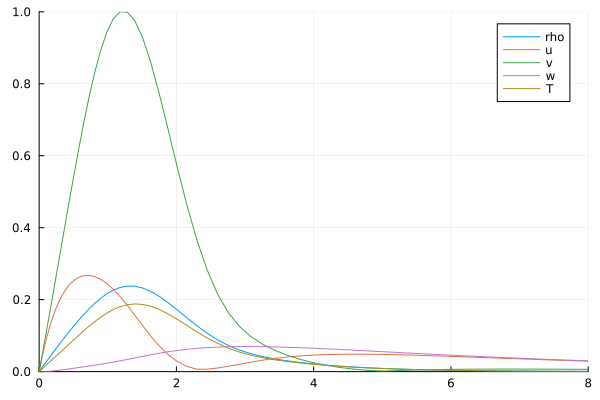

In [177]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8],ylims=[0,1]) 
plot!(z,abs.(vel[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

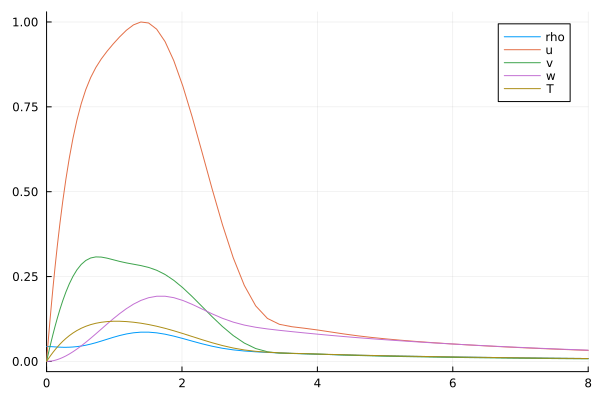

In [178]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8]) 
plot!(z,abs.(vel_A[2]),label = "u",xlims=[0,8])
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [ ]:
function pre_process(n,R,Mr,OMEGA,N_cheb,c,F,G,H,T,rho,z,lam,kappa,D,D2)
    omega = OMEGA/R
    be = n/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
    A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega,0)
    L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    nep = PEP([L0,L1,L2]);
    nep = PEP([L0_A,L1_A,L2_A]); 
    eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    eigval_A,eigvec_A = iar(nep,σ = c, neigs = 1 ,maxit = 500,tol = 1e-14)
    return eigval[1],eigval_A[1]
end

In [ ]:
function caculate_cr1(Tw,Mr,n,OMEGA,R_start,R_step,R_end)
    N_cheb = 199
    Ro = -1
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    num = 1
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    W,W_H = Wcc_fun(z,N_cheb)
    w1 = cheb_quad(N_cheb)
    c,c_A = pre_process(n,R_start,Mr,OMEGA,N_cheb,0.8,F,G,H,T,rho,z,lam,kappa,D,D2)
    coff = [0 0 0 0 0 0 0 0 0]
    c = 0.2-0.04im
        for R = R_start : R_step : R_end
            omega = OMEGA/R
            be = n/R
            Ma = Mr/R
            hr = 1;
            ls = 1/2;
            cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
            L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega)
            L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
            A0_raw,A1_raw,A2_raw = assemble_adjmat(cof,D,D2,be,omega,0)
            L0_A,L1_A,L2_A = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
            nep = PEP([L0,L1,L2]);
            nep1 = PEP([L0_A,L1_A,L2_A]); 
            eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
            vel_full,vel = eig_full(eigvec,N_cheb,1)
            eigval_A,eigvec_A = iar(nep1,σ = c, neigs = 1 ,maxit = 500,tol = 1e-13)        
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            c = eigval[1]  
            eigvec = eigvec./findmax(abs.(vel[3]))[1]
            eigvec_A = eigvec_A./findmax(abs.(vel_A[2]))[1]
            vel_full,vel = eig_full(eigvec,N_cheb,1)  
            vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
            # Q = ((eigvec_A[:,1]') * w1 * (L1 + (eigval[1] + eigval_A[1]') * L2) * eigvec[:,1])
            Q = transpose(eigvec_A[:,1]) * w1 * (L1 + (eigval[1] + eigval_A[1]) * L2) * eigvec[:,1]
            Hx = hr*exp(-(eigval[1])^2/(4*ls))
            u_wall = -(D*F)[1] * Hx
            v_wall = -(D*G)[1] * Hx
            w_wall = 0
            T_wall = -(D*T)[1] * Hx 
            item_2 = rho[1] * (D*vel_A[2])[1] * u_wall
            item_3 = rho[1] * (D*vel_A[3])[1] * v_wall
            item_5 = rho[1]^2 * (T[1]/sigma) * (D*vel_A[5])[1] * T_wall
            BC =  item_2 + item_3 + item_5
            Cr = abs(-im * BC/Q[1])
            # coff = [coff;[R Cr c]]
            coff = [coff;[n R Cr abs(Q[1]) abs(BC) real(eigval) imag(eigval) real(eigval_A) imag(eigval_A)]]
            writedlm("Cr_$(OMEGA)_$(n)_$(Mr)_$(Tw).dat",coff[2:end,:])
        end
    return coff
end


In [ ]:
int_alp = BSplineKit.interpolate(R_range, dat, BSplineOrder(4),Natural())
r_intep = range(300,700,1001)
alp_1 = int_alp.(r_intep)
plot(r_intep,alp_1)

In [ ]:
plot(r_intep,d1)

In [ ]:
d1,d2 = diff_10th_order(alp_1,0.4)
plot(r_intep,d1.* alp_1)

In [ ]:
for OMEGA = (4.0)
    for Mr = 0.3 
        for Tw = (0.8)
            n = 30
            R_start = 600
            R_step = 5
            if Tw == 1.2
                R_end = 800
            else 
                R_end = 800
            end
            coff = caculate_cr1(Tw,Mr,n,OMEGA,R_start,R_step,R_end)
        end
    end
end

In [ ]:
for n = 30 : 10 : 60
    data = readdlm("Cr_$(n)_$(Mr)_$(Tw)_ref.dat")
    r_range = range(300,600,100)
    Cr_intep = BSplineKit.interpolate(data[:,1], 0.98*data[:,2], BSplineOrder(4),Natural())
    data_new = [r_range Cr_intep.(r_range)]
    writedlm("Cr_$(n)_$(Mr)_$(Tw)_ref_intep.dat",data_new)
end

In [ ]:
plot(real(coff[2:end,2]),real(coff[2:end,3]))

In [ ]:
data1 = readdlm("Cr_30_0.3_0.8.dat")
inter_ai = BSplineKit.interpolate(data1[:,2],data1[:,7],BSplineOrder(4),Natural())
r_range = range(data1[1,2],data1[end,2],1000)
data_int = inter_ai.(r_range)
plot(r_range,data_int)

In [ ]:
d1,d2 = diff_10th_order(data_int,0.3003)
plot(r_range,d1)
# d2 = diff1(d1,2.5)
# plot(data1[:,2],d2)

In [234]:
x_grid = collect(300.0:5.0:700.0)
function smooth_curve(x::Float64, x_peak::Float64; x_lin_end::Float64=500.0)
    # 固定边界和高度条件
    x_start = 300.0
    x_end = 800.0
    y_start = 1.0
    y_end = 1.0
    y_peak = 1.2
    
    if x <= x_start
        return y_start
    elseif x >= x_end
        return y_end
    end

    # 动态计算安全的线性段斜率 k，确保导数平滑且无过冲
    k_max = 3.0 * (y_peak - y_start) / (x_peak + 2.0 * x_lin_end - 3.0 * x_start)
    k = 0.9 * k_max 
    
    y_lin_end = y_start + k * (x_lin_end - x_start)

    if x <= x_lin_end
        # 第一段：绝对的线性增长
        return y_start + k * (x - x_start)
        
    elseif x <= x_peak
        # 第二段：平滑过渡到峰值 (三次 Hermite 样条自适应求解)
        dx1 = x_peak - x_lin_end
        t = (x - x_lin_end) / dx1
        
        dy = y_peak - y_lin_end
        c_param = k * dx1
        a = -2.0 * dy + c_param
        b = 3.0 * dy - 2.0 * c_param
        
        # 使用 Horner 法则优化多项式计算速度
        return y_lin_end + t * (c_param + t * (b + a * t)) 
        
    else
        # 第三段：峰值后的平滑回落 (标准 Smoothstep)
        dx2 = x_end - x_peak
        t = (x - x_peak) / dx2
        
        t2 = t * t
        t3 = t2 * t
        return y_peak - (y_peak - y_end) * (3.0 * t2 - 2.0 * t3)
    end
end
Ma = 1.2
MAX = 600.0
data = readdlm("Cr_4.0_30_$(Ma)_0.8.dat")
y_bump = smooth_curve.(x_grid,MAX)
# plot(y_bump)
# plot(data[:,2],data[:,5] ./ (y_bump.*data[:,4]))
# plot!(data[:,2],data[:,3],ylims=[0.06,0.12])
data_new = [data data[:,5] ./ (y_bump.*data[:,4])]
writedlm("Cr_4.0_30_$(Ma)_0.8_new.dat",data_new)

In [ ]:
# =========================================================================
#  10阶中心差分导数求解器（带边界连续降阶功能）
#  适用场景：流体力学稳定性理论分析（高精度，低耗散）
# =========================================================================

using LinearAlgebra

"""
    fd_weights(grid_points, z, k)

计算有限差分系数的辅助函数。
输入：
- grid_points: 模板点的相对坐标数组 (例如 [-1, 0, 1])
- z: 求导点在相对坐标系中的位置 (通常为 0)
- k: 导数阶数 (1=一阶导, 2=二阶导)
输出：
- weights: 对应的差分系数向量
"""
function fd_weights(grid_points, z, k)
    n = length(grid_points)
    # 构建范德蒙德矩阵的转置 (Vandermonde system)
    # A * w = b
    # A_ij = (x_j)^i / i!
    # b_i = 1 if i == k, else 0
    
    A = zeros(Float64, n, n)
    b = zeros(Float64, n)
    
    for row in 1:n
        power = row - 1
        for col in 1:n
            A[row, col] = (grid_points[col] - z)^power / factorial(power)
        end
    end
    
    if k < n
        b[k+1] = 1.0
    end
    
    return A \ b
end

"""
    diff_10th_order(u, dx)

输入：
- u: 等间距网格上的函数值数组 (Vector)
- dx: 网格间距 (Float64)

输出：
- du: 一阶导数数组
- d2u: 二阶导数数组
"""
function diff_10th_order(u::Vector{T}, dx::T) where T <: AbstractFloat
    N = length(u)
    du = zeros(T, N)
    d2u = zeros(T, N)
    
    # === 1. 预计算所有需要的差分系数 ===
    # 键是(半径, 导数阶数)，值是系数向量
    # 半径 r 对应模板宽度 2r+1
    coeffs = Dict{Tuple{Int, Int}, Vector{Float64}}()
    
    # 中心差分系数 (r=1 到 r=5, 对应 2阶 到 10阶)
    for r in 1:5
        stencil = Float64.(collect(-r:r))
        coeffs[(r, 1)] = fd_weights(stencil, 0.0, 1)
        coeffs[(r, 2)] = fd_weights(stencil, 0.0, 2)
    end
    
    # 边界偏心差分系数 (使用3点，2阶精度)
    # 左边界 (求导点在索引1，模板为 1,2,3 -> 相对坐标 0,1,2)
    coeffs[(0, 1)] = fd_weights([0.0, 1.0, 2.0], 0.0, 1) # 左边界一阶
    coeffs[(0, 2)] = fd_weights([0.0, 1.0, 2.0], 0.0, 2) # 左边界二阶
    
    # === 2. 逐点计算导数 ===
    @inbounds for i in 1:N
        # 计算当前点左右可用的最大对称邻居数
        dist_left = i - 1
        dist_right = N - i
        radius = min(dist_left, dist_right)
        
        # 限制最大半径为5 (10阶精度)
        if radius > 5
            radius = 5
        end
        
        if radius == 0
            # --- 物理边界处理 (i=1 或 i=N) ---
            if i == 1
                # 左边界：使用前3点
                w1 = coeffs[(0, 1)]
                w2 = coeffs[(0, 2)]
                subset = u[1:3]
                
                du[i] = dot(w1, subset) / dx
                d2u[i] = dot(w2, subset) / dx^2
            else
                # 右边界：使用后3点 (利用对称性或重新计算，这里直接镜像处理)
                # 相当于对倒序的最后3点求负导数(一阶)或正导数(二阶)
                # 为清晰起见，显式计算右边界权重
                w1_r = fd_weights([-2.0, -1.0, 0.0], 0.0, 1)
                w2_r = fd_weights([-2.0, -1.0, 0.0], 0.0, 2)
                subset = u[end-2:end]
                
                du[i] = dot(w1_r, subset) / dx
                d2u[i] = dot(w2_r, subset) / dx^2
            end
            
        else
            # --- 内部点处理 (中心差分降阶) ---
            # radius=5 -> 10阶
            # radius=4 -> 8阶
            # ...
            # radius=1 -> 2阶
            
            w1 = coeffs[(radius, 1)]
            w2 = coeffs[(radius, 2)]
            
            # 获取对应的 stencil 数据
            subset = u[i-radius : i+radius]
            
            du[i] = dot(w1, subset) / dx
            d2u[i] = dot(w2, subset) / dx^2
        end
    end
    
    return du, d2u
end

# =========================================================================
#  验证测试模块
# =========================================================================

# 构造一个光滑函数进行测试：f(x) = sin(2x) * exp(-0.1x)
# 这类函数常见于稳定性分析的模态波形
x_min, x_max = 0.0, 10.0
N_grid = 101
dx = (x_max - x_min) / (N_grid - 1)
x = range(x_min, x_max, length=N_grid) |> collect

# 定义原函数及其解析导数
f(x) = sin(2x) * exp(-0.1x)
df_exact(x) = 2cos(2x)*exp(-0.1x) - 0.1sin(2x)*exp(-0.1x)
d2f_exact(x) = -4sin(2x)*exp(-0.1x) - 0.4cos(2x)*exp(-0.1x) + 0.01sin(2x)*exp(-0.1x)

u = f.(x)

# 运行差分程序
du_num, d2u_num = diff_10th_order(u, dx)
